In [34]:
import pandas as pd
from matplotlib import pyplot as plt
from datetime import datetime
from rapidfuzz import fuzz
from requests import post



In [2]:
license_data = pd.read_excel('../raw_data.xlsx', engine='openpyxl')
license_data['Start date'] = pd.to_datetime(license_data['Start date'], format='%m/%d/%Y')
license_data['Close date'] = pd.to_datetime(license_data['Close date'], format='%m/%d/%Y')

license_data = license_data[~ license_data['Start date'].isna()] # Remove all entries without a start date
license_data = license_data[license_data['Start date']  < pd.to_datetime(datetime.today())] # Only look at businesses who have already opened

license_data = license_data[license_data['Bus City, State'].fillna("").map(lambda x: fuzz.ratio('SAN LUIS OBISPO', x.upper())) > 50] # Only look at businesses in the city of slo

license_data = license_data[~ license_data['Bus address'].isna()] # Must have a bus address listed

license_data = license_data[license_data['Start date'] < license_data['Close date']] #Business must open before closing

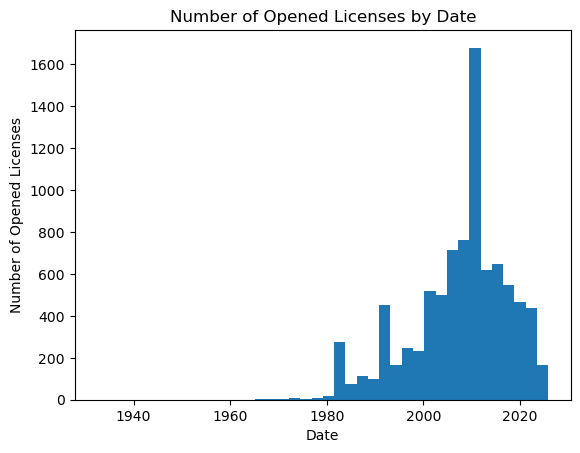

count                             8765
mean     2007-08-18 15:44:49.834569216
min                1932-07-01 00:00:00
25%                2002-03-13 00:00:00
50%                2010-01-27 00:00:00
75%                2014-07-14 00:00:00
max                2025-11-17 00:00:00
Name: Start date, dtype: object


In [3]:

license_data['Start date'].hist(
    bins=40,
)
plt.title("Number of Opened Licenses by Date")
plt.grid(False)
plt.xlabel("Date")
plt.ylabel("Number of Opened Licenses")
plt.show()
print(license_data['Start date'].describe())

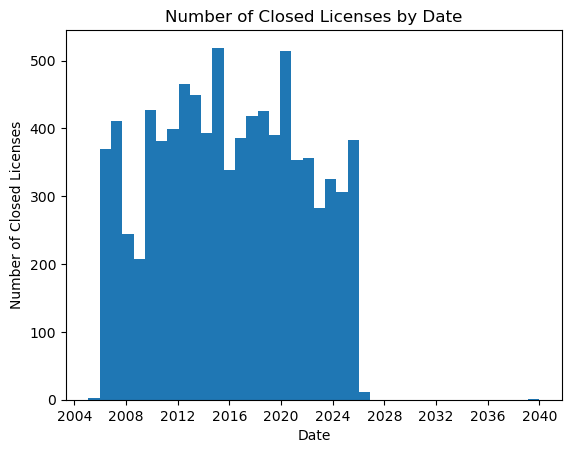

count                             8765
mean     2016-01-06 03:29:57.741015552
min                2005-02-01 00:00:00
25%                2011-06-30 00:00:00
50%                2015-12-01 00:00:00
75%                2020-06-30 00:00:00
max                2040-01-01 00:00:00
Name: Close date, dtype: object


In [4]:
license_data['Close date'].hist(
    bins=40,
)
plt.title("Number of Closed Licenses by Date")
plt.grid(False)
plt.xlabel("Date")
plt.ylabel("Number of Closed Licenses")
plt.show()
print(license_data['Close date'].describe())


In [5]:
close_times = pd.to_timedelta(pd.to_datetime(license_data['Close date'], format='%m/%d/%Y') - pd.to_datetime(license_data['Start date'], format='%m/%d/%Y'), unit='D').combine(pd.to_datetime(datetime.now()) -  pd.to_datetime(license_data['Start date']),
                  lambda d1,d2: d2 if d1 is None else d2).dt.days

close_times.name = 'closure_time'

censor = (~ license_data['Close date'].isna()).astype(int)

out_frame = close_times.to_frame()

out_frame['censor'] = censor

del close_times
del censor

out_frame

,closure_time,censor
0,7638,1
1,6114,1
2,5972,1
6,2558,1
8,3957,1
...,...,...
23753,4391,1
23759,1611,1
23760,11941,1
23763,9338,1


<Axes: title={'center': 'Number of Months until Business Closure'}, xlabel='Months', ylabel='Count'>

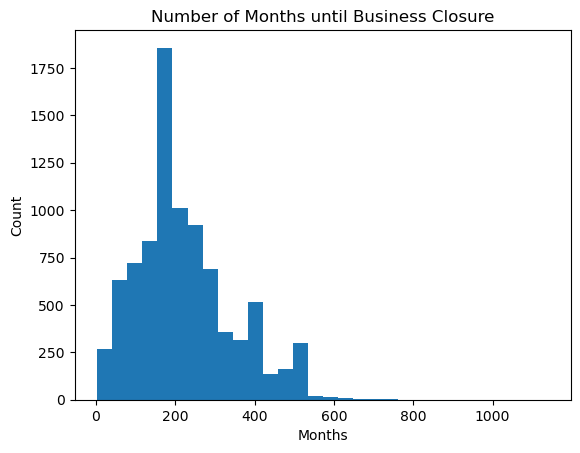

In [6]:
(out_frame['closure_time'] / 30).plot.hist(
    bins=30,
    xlabel='Months',
    ylabel='Count',
    title='Number of Months until Business Closure'
)

# Adding Zoning Locations

In [9]:
#Converted addresses to lat long with https://geocoding.geo.census.gov/geocoder/geographies/addressbatch

addr : pd.DataFrame = pd.concat([pd.read_csv('addr1_p.csv', header=None), pd.read_csv('addr2_p.csv', header=None)]).sort_values(by=0)


addr = pd.merge(out_frame.reset_index(),addr, left_on='index', right_on=0, how='left').drop(['index',0,6,7,8,9,10,11], axis=1)

locs = pd.DataFrame(addr[5].fillna(',').str.split(',').tolist())
out_frame = pd.concat([license_data,out_frame],axis=1).reset_index().drop(['Bus City, State', 'Account #', 'Owner Name 1','index'], axis=1)

In [10]:


out_frame['longitude'] = locs[0]
out_frame['latitude'] = locs[1]

In [100]:
bad_addr = out_frame[(out_frame['latitude'] == '') & ~ (out_frame['Bus address'].str.upper().str.contains('LOCATION')) ]['Bus address'] + ', San Luis Obispo, CA, 93401'

In [75]:
API_KEY=''
params = {
    "subscription-key": API_KEY
}



body = {'batchItems': [{"query":address} for address in bad_addr[200:]]}

out = post('https://atlas.microsoft.com/geocode:batch?api-version=2025-01-01',params=params,json=body).json()

out

{'batchItems': [{'type': 'FeatureCollection',
   'features': [{'type': 'Feature',
     'geometry': {'type': 'Point', 'coordinates': [-120.676363, 35.241632]},
     'bbox': [-120.68266872044023,
      35.237769282429326,
      -120.67005727955976,
      35.24549471757068],
     'properties': {'type': 'Address',
      'confidence': 'High',
      'matchCodes': ['Good'],
      'geocodePoints': [{'calculationMethod': 'Rooftop',
        'usageTypes': ['Display'],
        'geometry': {'type': 'Point',
         'coordinates': [-120.676363, 35.241632]}},
       {'calculationMethod': 'Rooftop',
        'usageTypes': ['Route'],
        'geometry': {'type': 'Point',
         'coordinates': [-120.6768207, 35.2418267]}}],
      'address': {'addressLine': '4251 S Higuera St',
       'streetName': 'S Higuera St',
       'streetNumber': '4251',
       'postalCode': '93401',
       'locality': 'San Luis Obispo',
       'formattedAddress': '4251 S Higuera St, San Luis Obispo, CA 93401',
       'countryRe

In [84]:
points = pd.DataFrame(points, columns=['latitude', 'longitude'])

In [164]:
new_bad = bad_addr.reset_index()
new_bad['longitude2'] = points['latitude']
new_bad['latitude2'] = points['longitude']


new_bad = new_bad.set_index('index')

In [185]:
new_frame = pd.DataFrame(pd.concat([out_frame, new_bad], axis=1))


new_frame['longitude'] = (new_frame['longitude'].map(lambda x: 0 if x == '' else float(x)) + new_frame['longitude2'].fillna(0))

new_frame['latitude'] = (new_frame['latitude'].map(lambda x: 0 if x == '' else float(x)) + new_frame['latitude2'].fillna(0))


new_frame[new_frame.columns.unique()].drop(['longitude2','latitude2'],axis=1).to_csv('cleaned.csv')